In [1343]:
from calendar import month

import pandas as pd
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import unique


In [1431]:
df =  pd.read_csv("Hipotecarios_Marginales febrero2024conBBVA.csv", encoding="latin1")
df.tail(5)

,sector,cve_periodo,nombre_publicacion,dl_estado,dl_municipio,dat_ingreso_mensual_bruto,dat_valor_vivienda_originacion,tipo_acreditado,dl_tipo_comprobacion,dat_ai_edad_acred,dl_genero,numero de crédito,dat_monto_orig_cred,dl_destino_credito,dl_producto_hipotecario,Tipo de Crédito,dl_segmento_vivienda,tasa_ponderada
1293603,SOCIEDADES FINANCIERAS DE OBJETO MULTIPLE,202210,ION Financiera,VERACRUZ DE IGNACIO DE LA LLAVE,VERACRUZ,138639.07,1768000.0,No Asalariado,No asalariado,39,Masculino,Crédito 1,1237600.0,Adquisición de Vivienda Usada,Adquiere tu casa ION,Sin cofinanciamiento,Interés Social,19.70
1293604,SOCIEDADES FINANCIERAS DE OBJETO MULTIPLE,202212,ION Financiera,NUEVO LEÓN,APODACA,536057.22,1775000.0,No Asalariado,No asalariado,35,Masculino,Crédito 1,1228975.0,Adquisición de Vivienda Usada,Adquiere tu casa ION,Sin cofinanciamiento,Media o Residencial,19.20
1293605,SOCIEDADES FINANCIERAS DE OBJETO MULTIPLE,202302,ION Financiera,MÉXICO,ZINACANTEPEC,44822.00,4072000.0,No Asalariado,No asalariado,53,Masculino,Crédito 1,500000.0,Crédito Para Liquidez,Liquidez Inmediata ION,Sin cofinanciamiento,Media o Residencial,22.25
1293606,SOCIEDADES FINANCIERAS DE OBJETO MULTIPLE,202303,ION Financiera,PUEBLA,QUECHOLAC,48672.00,1721000.0,No Asalariado,No asalariado,25,Femenino,Crédito 1,681000.0,Crédito Para Liquidez,Liquidez Inmediata ION,Sin cofinanciamiento,Interés Social,23.50
1293607,SOCIEDADES FINANCIERAS DE OBJETO MULTIPLE,202305,ION Financiera,QUINTANA ROO,COZUMEL,7485.00,212000.0,Asalariado Privado,Asalariado,55,Masculino,Crédito 1,133886.0,Adquisición de Vivienda Nueva,Adquiere tu casa ION,Sin cofinanciamiento,Interés Social,23.25


In [1432]:
df["cve_periodo"].unique().tolist()

[201901,
 201902,
 201903,
 201904,
 201905,
 201906,
 201907,
 201908,
 201909,
 201910,
 201911,
 201912,
 202001,
 202002,
 202003,
 202004,
 202005,
 202006,
 202007,
 202008,
 202009,
 202010,
 202011,
 202012,
 202101,
 202102,
 202103,
 202104,
 202105,
 202106,
 202107,
 202108,
 202109,
 202110,
 202111,
 202112,
 202201,
 202202,
 202203,
 202204,
 202205,
 202206,
 202207,
 202208,
 202209,
 202210,
 202211,
 202212,
 202301,
 202302,
 202303,
 202304,
 202305,
 202306,
 202307,
 202308,
 202309,
 202310,
 202311,
 202312,
 202401,
 202402]

In [1345]:
columns =  df.columns.to_list()


In [1346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1293608 entries, 0 to 1293607
Data columns (total 18 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   sector                          1293608 non-null  object 
 1   cve_periodo                     1293608 non-null  int64  
 2   nombre_publicacion              1293608 non-null  object 
 3   dl_estado                       1293607 non-null  object 
 4   dl_municipio                    1293607 non-null  object 
 5   dat_ingreso_mensual_bruto       1293608 non-null  float64
 6   dat_valor_vivienda_originacion  1293608 non-null  float64
 7   tipo_acreditado                 1293608 non-null  object 
 8   dl_tipo_comprobacion            1293608 non-null  object 
 9   dat_ai_edad_acred               1293608 non-null  int64  
 10  dl_genero                       1293608 non-null  object 
 11  numero de crédito               1293608 non-null  object 
 12  

## Estructura de la Base de Datos

### Variables Categóricas (7)
- **cve_periodo:** Fecha (año y mes)  
- **nombre_publicacion:** Nombre del banco  
- **dl_estado:** Estado  
- **tipo_acreditado:** Público o privado  
- **dl_tipo_comprobacion:** Asalariado o no asalariado  
- **dl_genero:** Género  
- **dl_destino_credito:** Destino del crédito  

### Variables Numéricas (5)
- **dat_ingreso:** Ingreso mensual bruto promedio  
- **dat_valor_vivienda_originacion:** Valor de la vivienda  
- **dat_ai_edad_acred:** Edad del acreditado  
- **dat_monto_orig_cred:** Monto del crédito  
- **tasa_ponderada:** Tasa de interés ponderada  


Delete the non matching columns with the data structure defined

In [1347]:
columns = [
    "cve_periodo",
    "nombre_publicacion",
    "dl_estado",
    "tipo_acreditado",
    "dl_tipo_comprobacion",
    "dl_genero",
    "dl_destino_credito",
    "dat_ingreso_mensual_bruto",
    "dat_valor_vivienda_originacion",
    "dat_ai_edad_acred",
    "dat_monto_orig_cred",
    "tasa_ponderada"
]

df_clean = df[columns]

In [1348]:
df_clean

,cve_periodo,nombre_publicacion,dl_estado,tipo_acreditado,dl_tipo_comprobacion,dl_genero,dl_destino_credito,dat_ingreso_mensual_bruto,dat_valor_vivienda_originacion,dat_ai_edad_acred,dat_monto_orig_cred,tasa_ponderada
0,201901,Banjército,SAN LUIS POTOSÍ,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Usada,55737.68,1800000.0,54,1928000.00,9.00
1,201901,Banjército,VERACRUZ DE IGNACIO DE LA LLAVE,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Nueva,23065.59,980000.0,47,1071951.08,9.00
2,201901,Banjército,YUCATÁN,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Usada,17034.54,558000.0,40,558000.00,9.00
3,201901,Banobras,OAXACA,Asalariado Público,Asalariado,Femenino,Adquisición de Vivienda Usada,53762.00,4137360.0,44,4114770.00,4.00
4,201902,Banjército,CIUDAD DE MÉXICO,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Usada,30589.15,1350000.0,26,1254239.28,9.00
...,...,...,...,...,...,...,...,...,...,...,...,...
1293603,202210,ION Financiera,VERACRUZ DE IGNACIO DE LA LLAVE,No Asalariado,No asalariado,Masculino,Adquisición de Vivienda Usada,138639.07,1768000.0,39,1237600.00,19.70
1293604,202212,ION Financiera,NUEVO LEÓN,No Asalariado,No asalariado,Masculino,Adquisición de Vivienda Usada,536057.22,1775000.0,35,1228975.00,19.20
1293605,202302,ION Financiera,MÉXICO,No Asalariado,No asalariado,Masculino,Crédito Para Liquidez,44822.00,4072000.0,53,500000.00,22.25
1293606,202303,ION Financiera,PUEBLA,No Asalariado,No asalariado,Femenino,Crédito Para Liquidez,48672.00,1721000.0,25,681000.00,23.50


In [1349]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1293608 entries, 0 to 1293607
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   cve_periodo                     1293608 non-null  int64  
 1   nombre_publicacion              1293608 non-null  object 
 2   dl_estado                       1293607 non-null  object 
 3   tipo_acreditado                 1293608 non-null  object 
 4   dl_tipo_comprobacion            1293608 non-null  object 
 5   dl_genero                       1293608 non-null  object 
 6   dl_destino_credito              1293608 non-null  object 
 7   dat_ingreso_mensual_bruto       1293608 non-null  float64
 8   dat_valor_vivienda_originacion  1293608 non-null  float64
 9   dat_ai_edad_acred               1293608 non-null  int64  
 10  dat_monto_orig_cred             1293608 non-null  float64
 11  tasa_ponderada                  1293608 non-null  float64
dtype

In [1350]:
df_clean.isnull().sum()


cve_periodo                       0
nombre_publicacion                0
dl_estado                         1
tipo_acreditado                   0
dl_tipo_comprobacion              0
dl_genero                         0
dl_destino_credito                0
dat_ingreso_mensual_bruto         0
dat_valor_vivienda_originacion    0
dat_ai_edad_acred                 0
dat_monto_orig_cred               0
tasa_ponderada                    0
dtype: int64

There 1 missing value at dl_estado class

Evaluate the actual class distribution to know which solution apply

In [1351]:

len(df["dl_estado"].unique().tolist())

33

In [1352]:
df_clean = df_clean.dropna(subset=["dl_estado"])
df_clean.isnull().sum()


cve_periodo                       0
nombre_publicacion                0
dl_estado                         0
tipo_acreditado                   0
dl_tipo_comprobacion              0
dl_genero                         0
dl_destino_credito                0
dat_ingreso_mensual_bruto         0
dat_valor_vivienda_originacion    0
dat_ai_edad_acred                 0
dat_monto_orig_cred               0
tasa_ponderada                    0
dtype: int64

By this time we opt to delete the whole row of the missing value as is just one missing value it's a good option to delete the whole row instead of apply more complex solutions as mode.


Convert the int64 data to float64. separate the categorical and numerical classes

In [1353]:
columns_categorical = [  
    "cve_periodo",
    "nombre_publicacion",
    "dl_estado",
    "tipo_acreditado",
    "dl_tipo_comprobacion",
    "dl_genero",
    "dl_destino_credito" ]
columns_numerical = [
    "dat_ingreso_mensual_bruto",
    "dat_valor_vivienda_originacion",
    "dat_ai_edad_acred",
    "dat_monto_orig_cred",
    "tasa_ponderada"
]

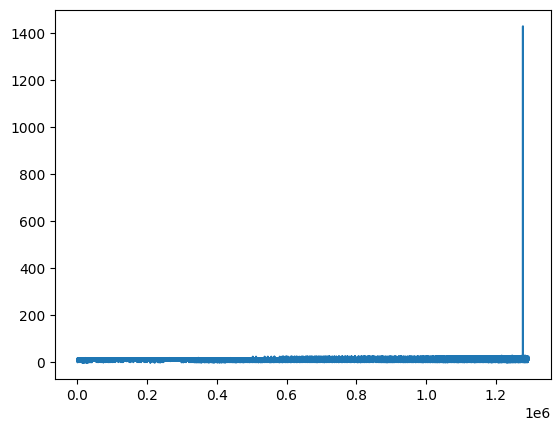

In [1354]:
plt.plot(df_clean["tasa_ponderada"])

In [1355]:
q01 = df_clean["tasa_ponderada"].quantile(0.01)
q99 = df_clean["tasa_ponderada"].quantile(0.999)

df_clean["tasa_ponderada"] = df_clean["tasa_ponderada"].clip(lower=q01, upper=q99)


C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\3480622148.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["tasa_ponderada"] = df_clean["tasa_ponderada"].clip(lower=q01, upper=q99)


6.5
24.0


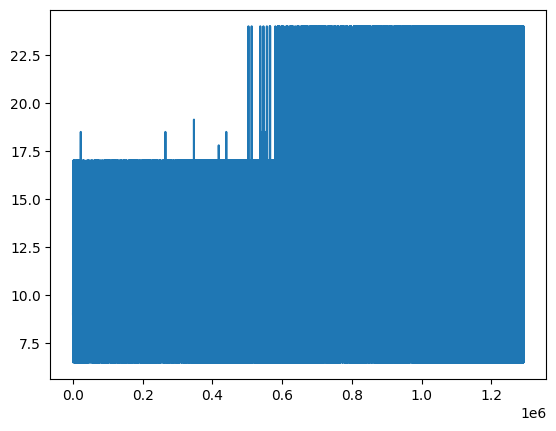

In [1356]:
plt.plot(df_clean["tasa_ponderada"])
print(df_clean["tasa_ponderada"].min())
print(df_clean["tasa_ponderada"].max())


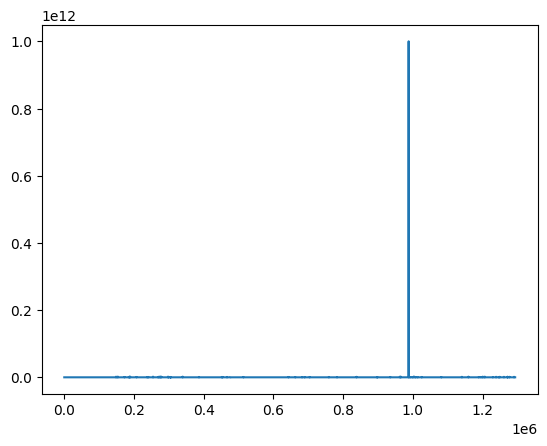

In [1357]:
plt.plot(df_clean["dat_ingreso_mensual_bruto"])

C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\199510040.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['dat_ingreso_mensual_bruto'] = df_clean['dat_ingreso_mensual_bruto'].clip(lower=q01, upper=q99)


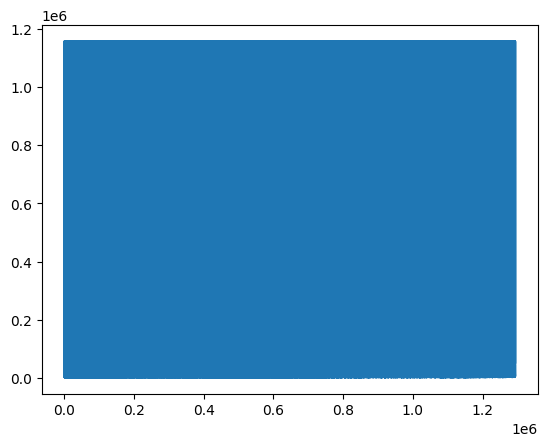

In [1358]:

q01 = df_clean['dat_ingreso_mensual_bruto'].quantile(0.01)
q99 = df_clean['dat_ingreso_mensual_bruto'].quantile(0.99)

df_clean['dat_ingreso_mensual_bruto'] = df_clean['dat_ingreso_mensual_bruto'].clip(lower=q01, upper=q99)

plt.plot(df_clean["dat_ingreso_mensual_bruto"])



In [1359]:
df_clean["dat_ingreso_mensual_bruto"].min()

2543.27216

0.01
148000000.0


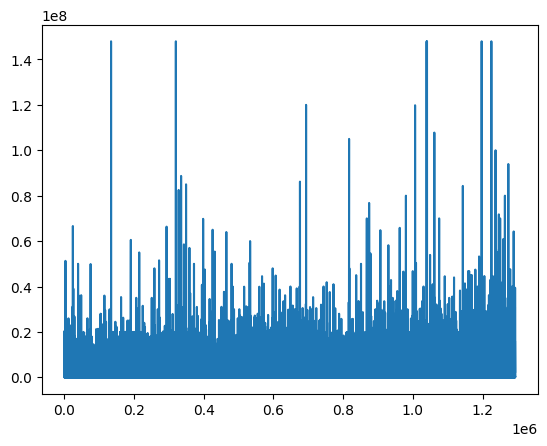

In [1360]:
plt.plot(df_clean["dat_monto_orig_cred"])
print(df_clean["dat_monto_orig_cred"].min())
print(df_clean["dat_monto_orig_cred"].max())

In [1361]:
q01 = df_clean["dat_monto_orig_cred"].quantile(0.01)
q99 = df_clean["dat_monto_orig_cred"].quantile(0.99)

df_clean["dat_monto_orig_cred"] = df_clean["dat_monto_orig_cred"].clip(lower=q01, upper=q99)

C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\3268813976.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["dat_monto_orig_cred"] = df_clean["dat_monto_orig_cred"].clip(lower=q01, upper=q99)


10095.8026
7200000.0


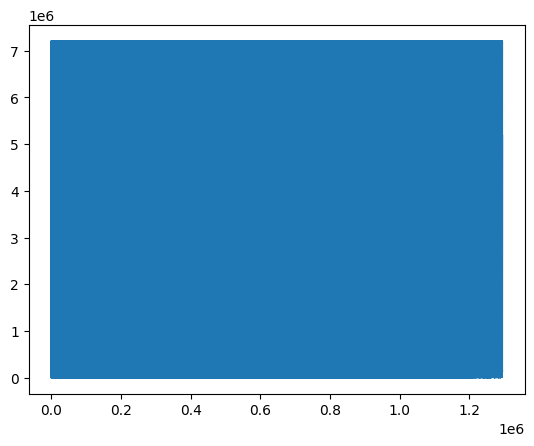

In [1362]:
plt.plot(df_clean["dat_monto_orig_cred"])
print(df_clean["dat_monto_orig_cred"].min())
print(df_clean["dat_monto_orig_cred"].max())

In [1363]:
df_clean = df_clean[~df_clean["dat_ai_edad_acred"].isin([81,82,85, 99])]

df_clean["dat_ai_edad_acred"].max()


80

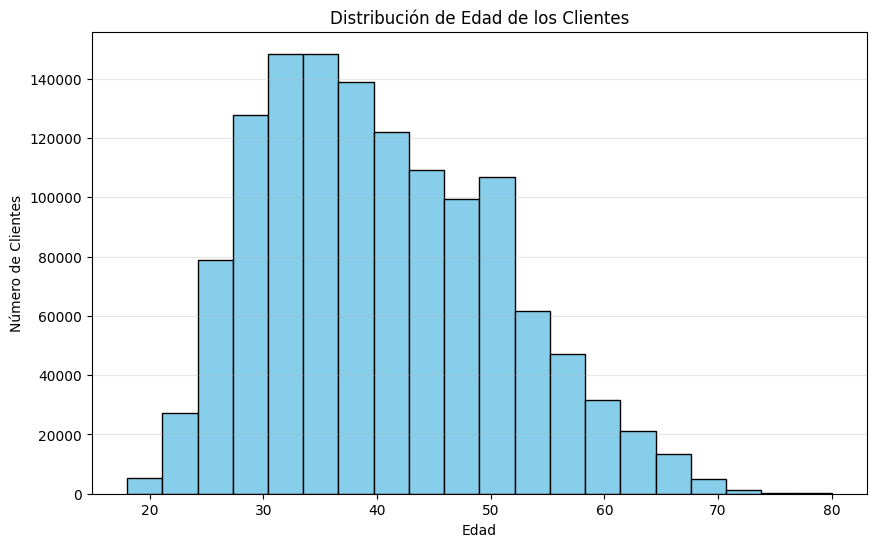

In [1364]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df_clean["dat_ai_edad_acred"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribución de Edad de los Clientes")
plt.xlabel("Edad")
plt.ylabel("Número de Clientes")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [1365]:
df.sort_values(by="dat_ingreso_mensual_bruto", ascending=False)[["dat_ingreso_mensual_bruto", "tipo_acreditado"]]

,dat_ingreso_mensual_bruto,tipo_acreditado
988008,1.000000e+12,Asalariado Privado
1003167,2.386963e+09,Asalariado Privado
153708,2.014558e+09,Asalariado Privado
1159443,1.931457e+09,Asalariado Privado
275877,1.928874e+09,Asalariado Privado
...,...,...
687896,1.000000e+00,Asalariado Privado
687927,1.000000e+00,Asalariado Privado
565978,1.000000e+00,Asalariado Privado
378663,1.000000e+00,Asalariado Privado


In [1366]:
df_nov23 = df_clean[df_clean['cve_periodo'] == 202311 ]
df_nov23

,cve_periodo,nombre_publicacion,dl_estado,tipo_acreditado,dl_tipo_comprobacion,dl_genero,dl_destino_credito,dat_ingreso_mensual_bruto,dat_valor_vivienda_originacion,dat_ai_edad_acred,dat_monto_orig_cred,tasa_ponderada
198,202311,Banjército,CHIAPAS,Asalariado Público,Asalariado,Masculino,Adquisición de Terreno para Vivienda,12544.50,568000.0,41,511200.0,10.0
199,202311,Banjército,CIUDAD DE MÉXICO,Asalariado Público,Asalariado,Masculino,Crédito Para Liquidez,73580.81,6981000.0,42,2000000.0,13.0
200,202311,Banjército,CIUDAD DE MÉXICO,Asalariado Público,Asalariado,Femenino,Adquisición de Vivienda Usada,19813.76,3035000.0,49,935000.0,9.0
201,202311,Banjército,PUEBLA,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Nueva,47490.93,2405000.0,42,520000.0,9.0
202,202311,Banjército,YUCATÁN,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Nueva,66805.12,3638000.0,33,2658000.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1290886,202311,Scotiabank,YUCATÁN,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Nueva,45815.00,1862000.0,30,1768900.0,11.0
1290887,202311,Scotiabank,YUCATÁN,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Usada,49595.25,1400000.0,36,1103050.0,11.8
1290888,202311,Scotiabank,YUCATÁN,No Asalariado,No asalariado,Femenino,Adquisición de Vivienda Usada,65274.21,1560000.0,40,1404000.0,11.0
1290889,202311,Scotiabank,YUCATÁN,No Asalariado,No asalariado,Masculino,Adquisición de Vivienda Nueva,198000.00,9830000.0,49,7200000.0,10.0


In [1367]:
df_nov23["nombre_publicacion"].unique().tolist()

['Banjército',
 'Afirme',
 'Banamex',
 'Banca Mifel',
 'Banorte',
 'Banregio',
 'BBVA México',
 'CIBanco',
 'HSBC',
 'Santander',
 'Scotiabank',
 'Ve por Más',
 'Inbursa',
 'Banco del Bajío',
 'Banco Azteca']

In [1368]:
df_nov23_s = df_nov23[df_nov23["nombre_publicacion"] == 'Scotiabank']
df_nov23_s

,cve_periodo,nombre_publicacion,dl_estado,tipo_acreditado,dl_tipo_comprobacion,dl_genero,dl_destino_credito,dat_ingreso_mensual_bruto,dat_valor_vivienda_originacion,dat_ai_edad_acred,dat_monto_orig_cred,tasa_ponderada
1187690,202311,Scotiabank,AGUASCALIENTES,Asalariado Privado,Asalariado,Femenino,"Mejoras, Ampliaciones y/o Remodelaciones",119775.70,750000.0,37,750000.0,10.0
1187691,202311,Scotiabank,AGUASCALIENTES,Asalariado Público,Asalariado,Femenino,Adquisición de Vivienda Nueva,27936.78,2129000.0,45,1000000.0,10.0
1187692,202311,Scotiabank,BAJA CALIFORNIA,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Usada,80326.73,2871000.0,53,2700000.0,11.8
1187693,202311,Scotiabank,BAJA CALIFORNIA,Asalariado Privado,Asalariado,Femenino,Adquisición de Vivienda Nueva,36663.00,2307000.0,37,2186500.0,10.5
1187694,202311,Scotiabank,BAJA CALIFORNIA,Asalariado Privado,Asalariado,Femenino,Adquisición de Vivienda Usada,60665.10,3739000.0,29,2110000.0,10.5
...,...,...,...,...,...,...,...,...,...,...,...,...
1290886,202311,Scotiabank,YUCATÁN,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Nueva,45815.00,1862000.0,30,1768900.0,11.0
1290887,202311,Scotiabank,YUCATÁN,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Usada,49595.25,1400000.0,36,1103050.0,11.8
1290888,202311,Scotiabank,YUCATÁN,No Asalariado,No asalariado,Femenino,Adquisición de Vivienda Usada,65274.21,1560000.0,40,1404000.0,11.0
1290889,202311,Scotiabank,YUCATÁN,No Asalariado,No asalariado,Masculino,Adquisición de Vivienda Nueva,198000.00,9830000.0,49,7200000.0,10.0


In [1369]:
scotiabank_total_cred = df_nov23_s['dat_monto_orig_cred'].sum()
cred_total = df_nov23['dat_monto_orig_cred'].sum()

total_scbnk_cred_participation_ = (scotiabank_total_cred / cred_total) * 100
total_scbnk_cred_participation_

np.float64(21.39638792804581)

In [1370]:
def market_participation(df):
    total = df["dat_monto_orig_cred"].sum()
    participation = (
        df.groupby("nombre_publicacion")["dat_monto_orig_cred"]
        .sum()
        .reset_index()
    )
    participation["participacion_%"] = (participation["dat_monto_orig_cred"] / total) * 100
    return participation.sort_values(by="participacion_%", ascending=False)


In [1371]:
scbnk_mrkt_results= market_participation(df_nov23)
scbnk_mrkt_results


,nombre_publicacion,dat_monto_orig_cred,participacion_%
1,BBVA México,5.716112e+09,26.319267
13,Scotiabank,4.646944e+09,21.396388
7,Banorte,3.701315e+09,17.042337
12,Santander,3.283755e+09,15.119724
10,HSBC,2.685155e+09,12.363528
2,Banamex,8.256253e+08,3.801509
8,Banregio,3.026473e+08,1.393509
0,Afirme,2.673485e+08,1.230979
6,Banjército,9.454615e+07,0.435328
3,Banca Mifel,7.369210e+07,0.339308


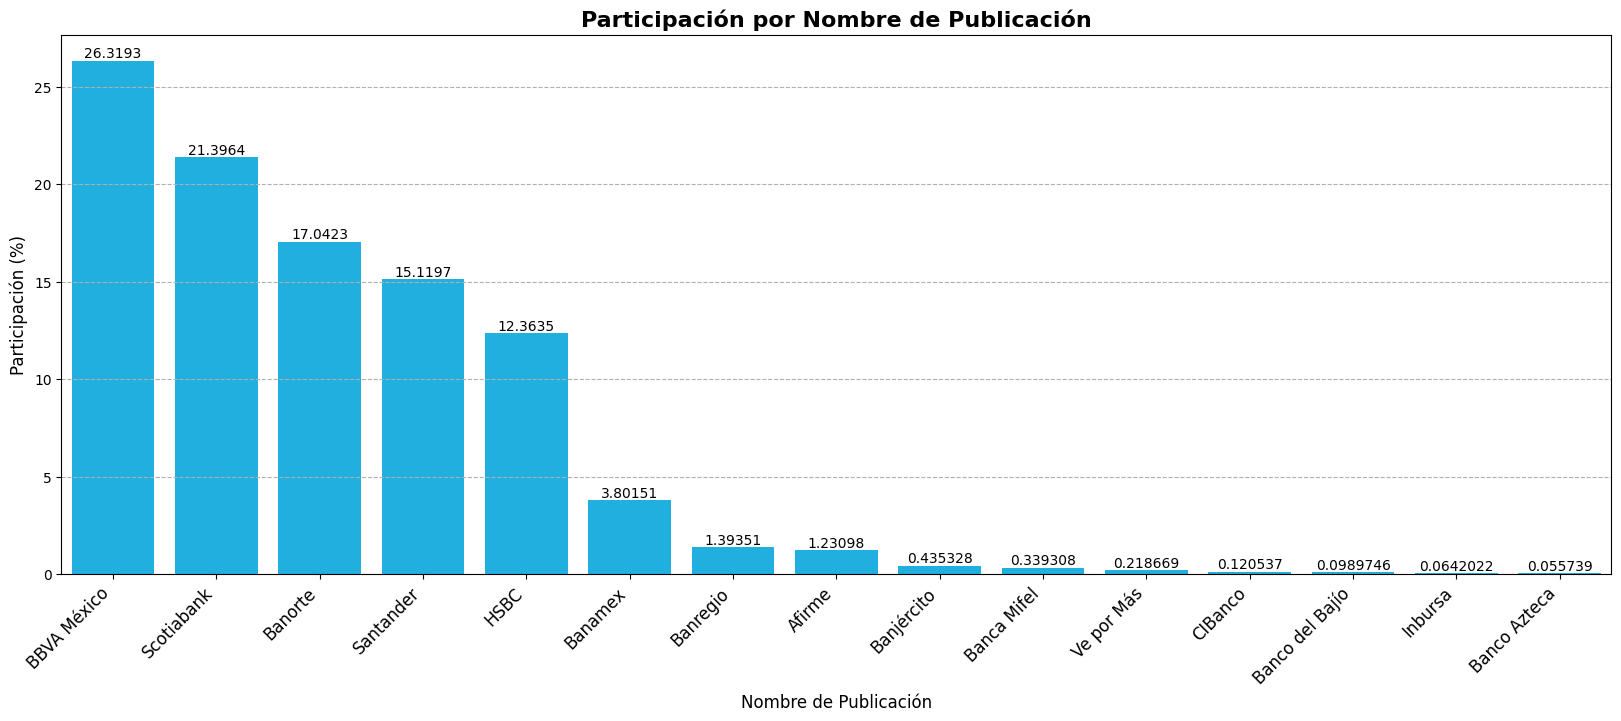

In [1372]:
plt.figure(figsize=(20, 7))

ax = sns.barplot(scbnk_mrkt_results,x="nombre_publicacion",y="participacion_%",color="#00BFFF")
ax.bar_label(ax.containers[0], fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.title('Participación por Nombre de Publicación', fontsize=16, weight='bold')
plt.ylabel('Participación (%)', fontsize=12)
plt.xlabel('Nombre de Publicación', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

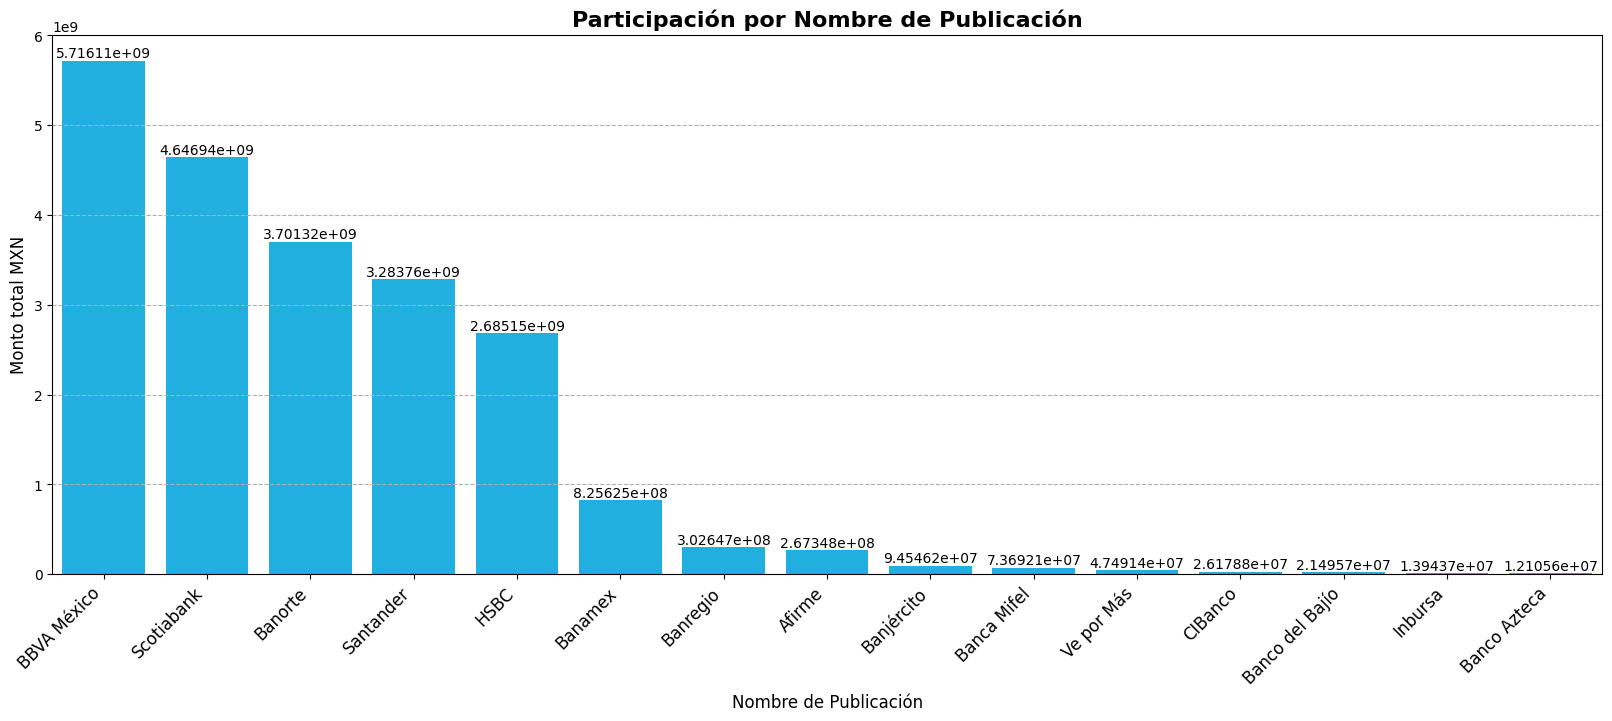

In [1373]:
plt.figure(figsize=(20, 7))

ax = sns.barplot(scbnk_mrkt_results,x="nombre_publicacion",y="dat_monto_orig_cred",color="#00BFFF")
ax.bar_label(ax.containers[0], fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.title('Participación por Nombre de Publicación', fontsize=16, weight='bold')
plt.ylabel('Monto total MXN', fontsize=12)
plt.xlabel('Nombre de Publicación', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

In [1374]:
len(df_clean["cve_periodo"].unique().tolist())

62

In [1375]:
# Agrupa por mes y banco
monthly = df_clean.groupby(['cve_periodo', 'nombre_publicacion'])['dat_monto_orig_cred'].sum().reset_index()
monthly


,cve_periodo,nombre_publicacion,dat_monto_orig_cred
0,201901,Afirme,1.004593e+08
1,201901,Autofin,7.816261e+06
2,201901,BBVA México,3.248320e+09
3,201901,Banamex,5.133125e+08
4,201901,Banca Mifel,9.144165e+08
...,...,...,...
1136,202402,HSBC,2.398601e+09
1137,202402,Inbursa,1.621179e+07
1138,202402,Santander,3.020668e+09
1139,202402,Scotiabank,4.686068e+09


In [1376]:
# Total de créditos por mes de todos los bancos
total_monthly = monthly.groupby('cve_periodo')['dat_monto_orig_cred'].sum().reset_index()
total_monthly.rename(columns={'dat_monto_orig_cred':'total_cred'}, inplace=True)
total_monthly

,cve_periodo,total_cred
0,201901,1.202597e+10
1,201902,1.395397e+10
2,201903,1.759710e+10
3,201904,1.520304e+10
4,201905,1.754503e+10
...,...,...
57,202310,2.241018e+10
58,202311,2.171836e+10
59,202312,2.513545e+10
60,202401,1.647351e+10


In [1377]:
monthly = monthly.merge(total_monthly, on='cve_periodo')
monthly

,cve_periodo,nombre_publicacion,dat_monto_orig_cred,total_cred
0,201901,Afirme,1.004593e+08,1.202597e+10
1,201901,Autofin,7.816261e+06,1.202597e+10
2,201901,BBVA México,3.248320e+09,1.202597e+10
3,201901,Banamex,5.133125e+08,1.202597e+10
4,201901,Banca Mifel,9.144165e+08,1.202597e+10
...,...,...,...,...
1136,202402,HSBC,2.398601e+09,2.124527e+10
1137,202402,Inbursa,1.621179e+07,2.124527e+10
1138,202402,Santander,3.020668e+09,2.124527e+10
1139,202402,Scotiabank,4.686068e+09,2.124527e+10


In [1378]:
monthly['participacion_%'] = (monthly['dat_monto_orig_cred'] / monthly['total_cred']) * 100
monthly

,cve_periodo,nombre_publicacion,dat_monto_orig_cred,total_cred,participacion_%
0,201901,Afirme,1.004593e+08,1.202597e+10,0.835353
1,201901,Autofin,7.816261e+06,1.202597e+10,0.064995
2,201901,BBVA México,3.248320e+09,1.202597e+10,27.010877
3,201901,Banamex,5.133125e+08,1.202597e+10,4.268367
4,201901,Banca Mifel,9.144165e+08,1.202597e+10,7.603681
...,...,...,...,...,...
1136,202402,HSBC,2.398601e+09,2.124527e+10,11.290048
1137,202402,Inbursa,1.621179e+07,2.124527e+10,0.076308
1138,202402,Santander,3.020668e+09,2.124527e+10,14.218076
1139,202402,Scotiabank,4.686068e+09,2.124527e+10,22.056997


In [1379]:
scbnk_monthly = monthly[monthly['nombre_publicacion'] == 'Scotiabank']
scbnk_monthly

,cve_periodo,nombre_publicacion,dat_monto_orig_cred,total_cred,participacion_%
20,201901,Scotiabank,1.547258e+09,1.202597e+10,12.865969
41,201902,Scotiabank,2.130664e+09,1.395397e+10,15.269229
62,201903,Scotiabank,1.979616e+09,1.759710e+10,11.249671
85,201904,Scotiabank,1.793622e+09,1.520304e+10,11.797783
106,201905,Scotiabank,2.073874e+09,1.754503e+10,11.820288
...,...,...,...,...,...
1078,202310,Scotiabank,4.895364e+09,2.241018e+10,21.844374
1093,202311,Scotiabank,4.646944e+09,2.171836e+10,21.396388
1108,202312,Scotiabank,5.809893e+09,2.513545e+10,23.114342
1124,202401,Scotiabank,3.791936e+09,1.647351e+10,23.018381


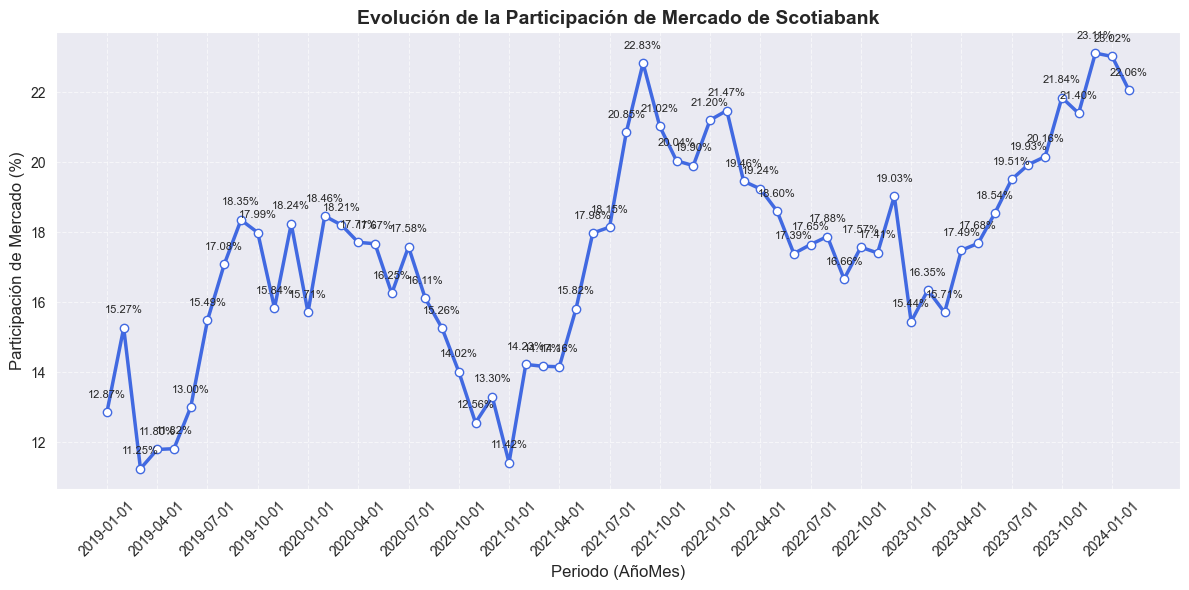

In [1466]:
import numpy as np
import matplotlib.pyplot as plt

# Series
y = scbnk_monthly["participacion_%"].values
x = np.arange(len(y))                       # coordenadas X explícitas
x_labels = scbnk_monthly["cve_periodo"].astype(str).values  # etiquetas (ej. '202311')

plt.figure(figsize=(12, 6))

# Dibuja la línea con puntos usando x explícito
plt.plot(x, y,
         color="royalblue", linewidth=2.5,
         marker="o", markersize=6,
         markerfacecolor="white", markeredgecolor="royalblue")

# Añadir etiquetas encima de cada punto (opcional: solo cada n puntos para no saturar)
label_every = 1   # poner 1 para todos, 3 para cada 3 meses, etc.
y_offset = (y.max() - y.min()) * 0.03  # offset dinámico del 3% del rango para separar texto del punto

for i, val in enumerate(y):
    if i % label_every == 0:
        plt.text(i, val + y_offset, f"{val:.2f}%", ha='center', va='bottom', fontsize=8)

# Configurar ticks del eje X (mostrar todos o solo algunos)
tick_step = max(1, len(x)//16)   # máximo ~12 ticks visibles
plt.xticks(ticks=x[::tick_step], labels=x_labels[::tick_step], rotation=45)

plt.title("Evolución de la Participación de Mercado de Scotiabank", fontsize=14, fontweight="bold")
plt.xlabel("Periodo (AñoMes)", fontsize=12)
plt.ylabel("Participación de Mercado (%)", fontsize=12)
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [1381]:
scbnk_monthly["cve_periodo"] = pd.to_datetime(scbnk_monthly["cve_periodo"].astype(str), format="%Y%m")


C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\1099811020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scbnk_monthly["cve_periodo"] = pd.to_datetime(scbnk_monthly["cve_periodo"].astype(str), format="%Y%m")


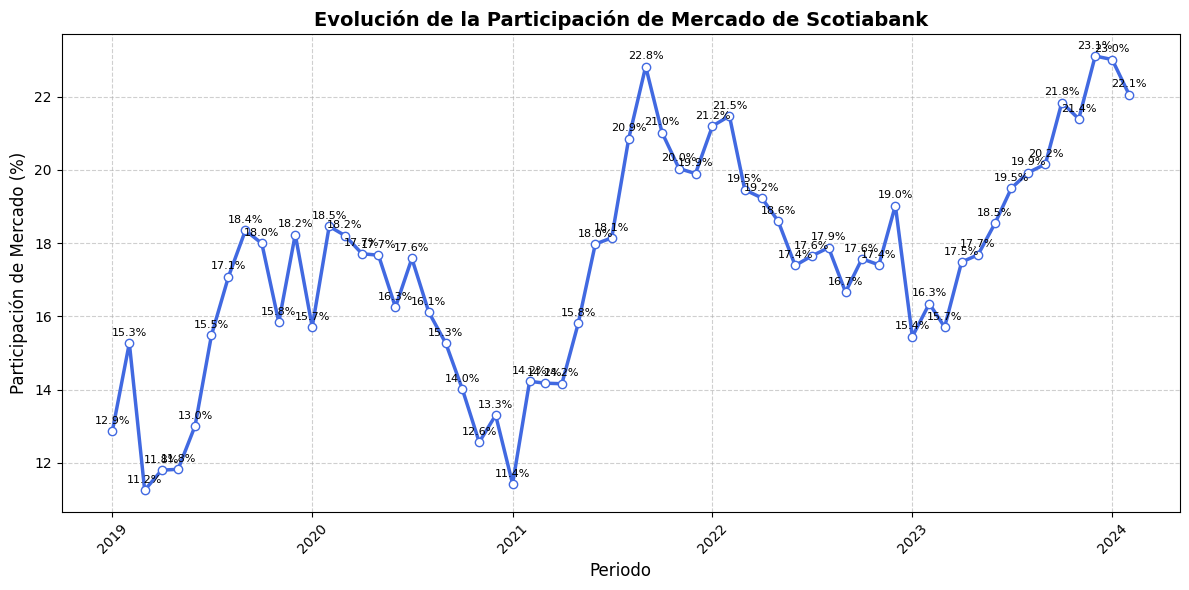

In [1382]:
plt.figure(figsize=(12, 6))

plt.plot(
    scbnk_monthly["cve_periodo"], 
    scbnk_monthly["participacion_%"],
    color="royalblue",
    linewidth=2.5,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor="royalblue"
)

plt.title("Evolución de la Participación de Mercado de Scotiabank", fontsize=14, fontweight="bold")
plt.xlabel("Periodo", fontsize=12)
plt.ylabel("Participación de Mercado (%)", fontsize=12)

plt.grid(True, which='major', linestyle='--', alpha=0.6)
for x, y in zip(scbnk_monthly["cve_periodo"], scbnk_monthly["participacion_%"]):
    
    plt.text(x, y + 0.2, f"{y:.1f}%", ha='center', fontsize=8)
# Rotar etiquetas de fecha automáticamente
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



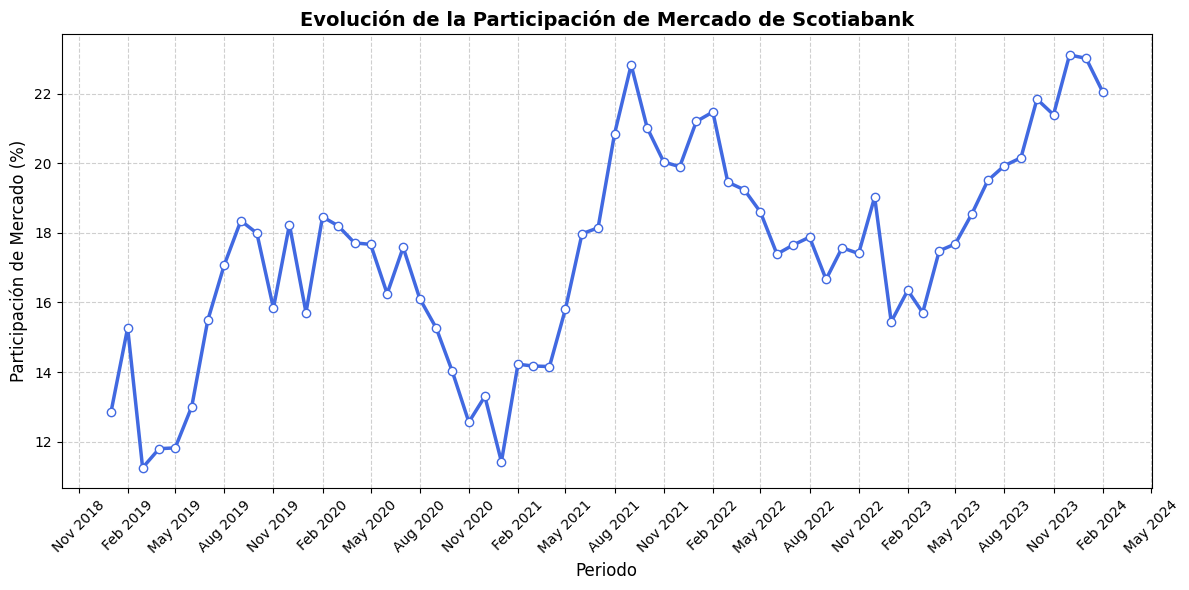

In [1383]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(
    scbnk_monthly["cve_periodo"],
    scbnk_monthly["participacion_%"],
    color="royalblue", linewidth=2.5, marker="o", markersize=6,
    markerfacecolor="white", markeredgecolor="royalblue"
)

plt.title("Evolución de la Participación de Mercado de Scotiabank", fontsize=14, fontweight="bold")
plt.xlabel("Periodo", fontsize=12)
plt.ylabel("Participación de Mercado (%)", fontsize=12)

# Mostrar ticks cada 3 meses
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [1384]:
bank_names = monthly["nombre_publicacion"].unique().tolist()
bank_names

['Afirme',
 'Autofin',
 'BBVA México',
 'Banamex',
 'Banca Mifel',
 'Banco Ahorro Famsa',
 'Banco del Bajío',
 'Banjército',
 'Banobras',
 'Banorte',
 'Banregio',
 'Bansí',
 'CIBanco',
 'HSBC',
 'ION Financiera',
 'Inbursa',
 'Monex',
 'Multiva',
 'Santander',
 'Santander Vivienda',
 'Scotiabank',
 'Ve por Más',
 'Banco Azteca',
 'Nafin',
 'Bancomext',
 'Invex',
 'Bancoppel',
 'Metrofinanciera',
 'Inmobiliario Mexicano',
 'Sabadell']

Top 5 bancos: ['BBVA México', 'Banorte', 'Scotiabank']


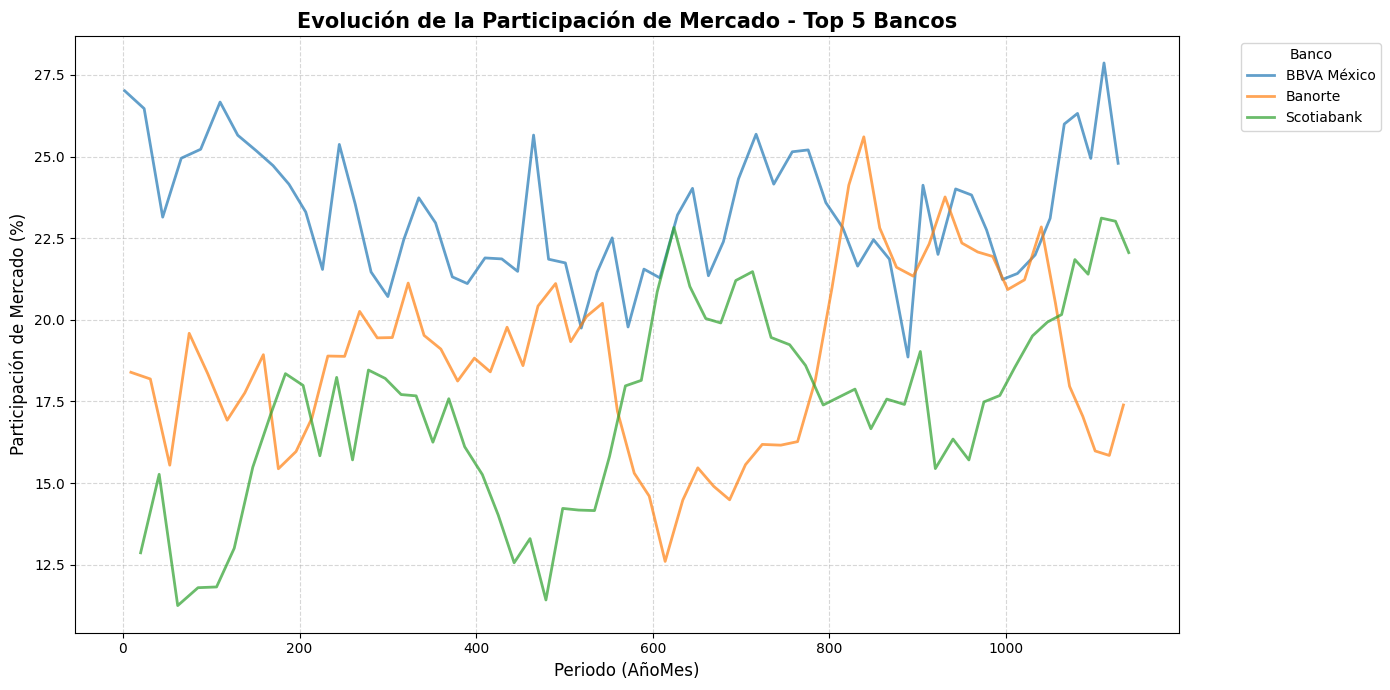

In [1385]:
# Calcular participación promedio por banco
avg_participation = monthly.groupby("nombre_publicacion")["participacion_%"].mean().sort_values(ascending=False)

# Seleccionar los top 5 bancos
top5_banks = avg_participation.head(3).index.tolist()
print("Top 5 bancos:", top5_banks)

plt.figure(figsize=(14, 7))

for bank in top5_banks:
    data = monthly[monthly["nombre_publicacion"] == bank]
    
    if bank.upper() == "Scotiabank":  # resaltar Scotiabank
        plt.plot(
            data["participacion_%"],
            color="crimson", linewidth=3,
            marker="o", markersize=7,
            markerfacecolor="white", markeredgecolor="crimson",
            label=bank
        )
    else:
        plt.plot(
            data["participacion_%"],
            linewidth=2, alpha=0.7,
            label=bank
        )

plt.title("Evolución de la Participación de Mercado - Top 5 Bancos", fontsize=15, fontweight="bold")
plt.xlabel("Periodo (AñoMes)", fontsize=12)
plt.ylabel("Participación de Mercado (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Leyenda fuera del gráfico
plt.legend(title="Banco", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


Top 5 bancos: ['BBVA México', 'Banorte', 'Scotiabank', 'Santander', 'HSBC']


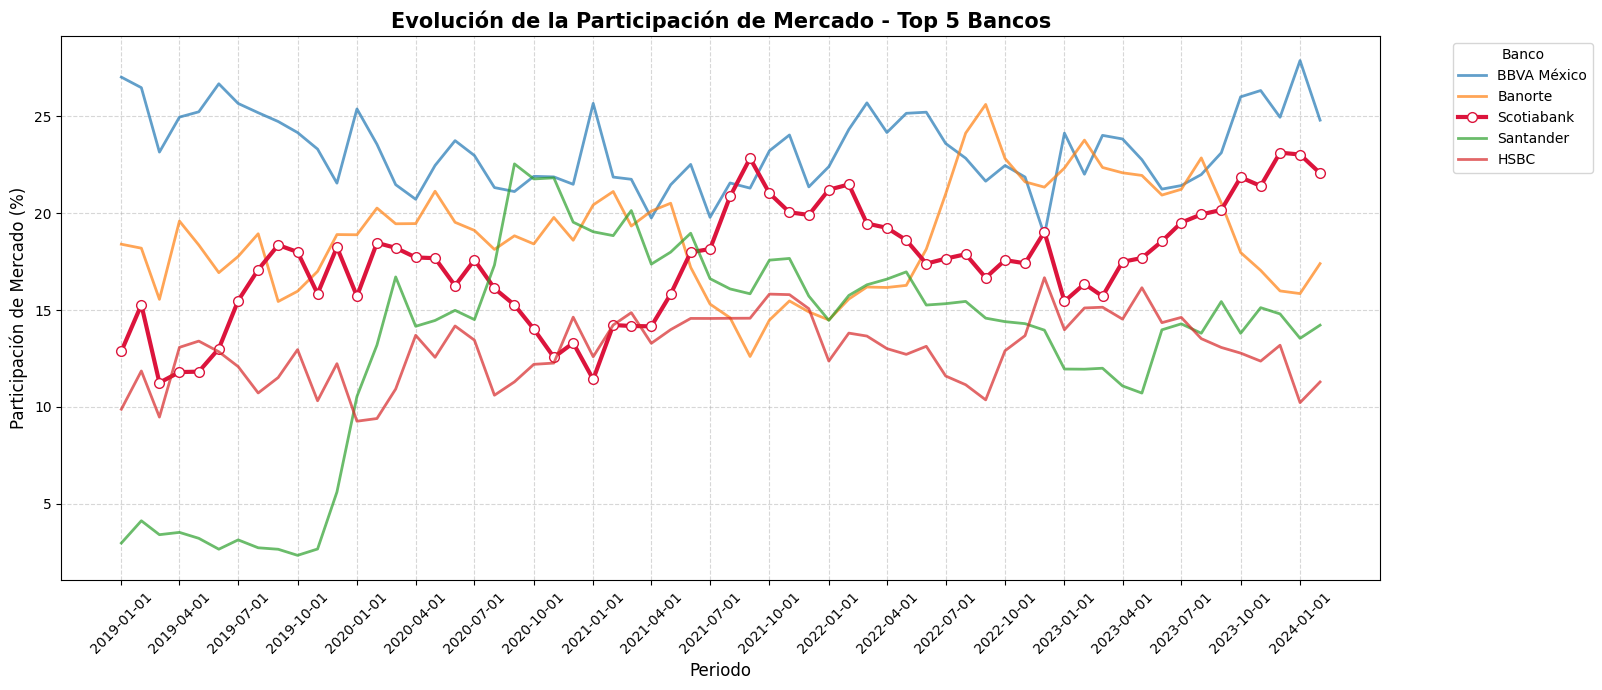

In [1386]:
monthly["fecha"] = pd.to_datetime(monthly["cve_periodo"].astype(str), format="%Y%m")

# Calcular participación promedio por banco
avg_participation = monthly.groupby("nombre_publicacion")["participacion_%"].mean().sort_values(ascending=False)

# Seleccionar los top 5 bancos
top5_banks = avg_participation.head(5).index.tolist()
print("Top 5 bancos:", top5_banks)

plt.figure(figsize=(14, 7))

# --- Graficar cada banco ---
for bank in top5_banks:
    data = monthly[monthly["nombre_publicacion"] == bank]
    
    if bank.lower() == "scotiabank":  # resalta Scotiabank
        plt.plot(
            data["fecha"], data["participacion_%"],
            color="crimson", linewidth=3,
            marker="o", markersize=7,
            markerfacecolor="white", markeredgecolor="crimson",
            label=bank
        )
    else:
        plt.plot(
            data["fecha"], data["participacion_%"],
            linewidth=2, alpha=0.7,
            label=bank
        )

# --- Personalización del gráfico ---
plt.title("Evolución de la Participación de Mercado - Top 5 Bancos", fontsize=15, fontweight="bold")
plt.xlabel("Periodo", fontsize=12)
plt.ylabel("Participación de Mercado (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# --- Mostrar más etiquetas del eje X ---
plt.xticks(
    ticks=pd.date_range(monthly["fecha"].min(), monthly["fecha"].max(), freq='3MS'),  # cada 3 meses aprox.
    rotation=45
)
plt.tight_layout()

# --- Leyenda fuera del gráfico ---
plt.legend(title="Banco", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.show()

In [1387]:
top5_summary = monthly.groupby("nombre_publicacion")["dat_monto_orig_cred"].sum()
top5_summary = (top5_summary / top5_summary.sum() * 100).sort_values(ascending=False).head(5)
print(top5_summary)


nombre_publicacion
BBVA México    23.131529
Banorte        18.773749
Scotiabank     17.615729
Santander      13.741939
HSBC           13.150648
Name: dat_monto_orig_cred, dtype: float64


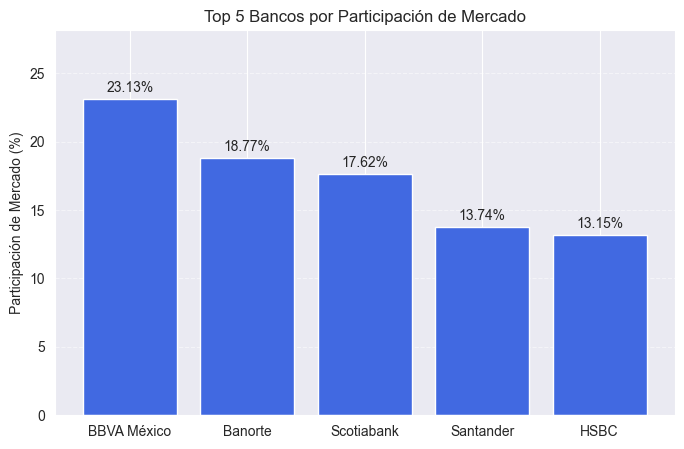

In [1471]:
# Gráfico de barras
plt.figure(figsize=(8,5))
bars = plt.bar(top5_summary.index, top5_summary.values, color='royalblue')

# Agregar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.ylabel('Participación de Mercado (%)')
plt.title('Top 5 Bancos por Participación de Mercado')
plt.ylim(0, top5_summary.values.max() + 5)  # margen superior
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [1388]:
monthly

,cve_periodo,nombre_publicacion,dat_monto_orig_cred,total_cred,participacion_%,fecha
0,201901,Afirme,1.004593e+08,1.202597e+10,0.835353,2019-01-01
1,201901,Autofin,7.816261e+06,1.202597e+10,0.064995,2019-01-01
2,201901,BBVA México,3.248320e+09,1.202597e+10,27.010877,2019-01-01
3,201901,Banamex,5.133125e+08,1.202597e+10,4.268367,2019-01-01
4,201901,Banca Mifel,9.144165e+08,1.202597e+10,7.603681,2019-01-01
...,...,...,...,...,...,...
1136,202402,HSBC,2.398601e+09,2.124527e+10,11.290048,2024-02-01
1137,202402,Inbursa,1.621179e+07,2.124527e+10,0.076308,2024-02-01
1138,202402,Santander,3.020668e+09,2.124527e+10,14.218076,2024-02-01
1139,202402,Scotiabank,4.686068e+09,2.124527e+10,22.056997,2024-02-01


In [1389]:
BBVA_Scotiabank_geography = df_clean[
    (df_clean["nombre_publicacion"] == "BBVA México") |
    (df_clean["nombre_publicacion"] == "Scotiabank")
]
BBVA_Scotiabank_geography["nombre_publicacion"].unique().tolist()

['BBVA México', 'Scotiabank']

In [1390]:
states_BBVA_SCBNK = BBVA_Scotiabank_geography.groupby(["nombre_publicacion","dl_estado"])["dat_monto_orig_cred"].sum().unstack("nombre_publicacion")

In [1391]:
states_BBVA_SCBNK

nombre_publicacion,BBVA México,Scotiabank
dl_estado,,
AGUASCALIENTES,4.205774e+09,3.154060e+09
BAJA CALIFORNIA,1.047306e+10,3.778507e+09
BAJA CALIFORNIA SUR,3.822239e+09,1.025415e+09
CAMPECHE,1.088282e+09,3.085737e+08
CHIAPAS,2.102032e+09,1.183053e+09
CHIHUAHUA,1.169072e+10,9.192712e+09
CIUDAD DE MÉXICO,3.661242e+10,4.175078e+10
COAHUILA DE ZARAGOZA,6.693331e+09,7.791053e+09
COLIMA,1.505251e+09,1.311721e+09


In [1392]:
# Calcular proporción Scotiabank / BBVA
states_BBVA_SCBNK["ratio_SCBNK_vs_BBVA"] = (
    states_BBVA_SCBNK["Scotiabank"] / states_BBVA_SCBNK["BBVA México"]
)

# Ordenar de mayor a menor
top5_states = states_BBVA_SCBNK.sort_values("ratio_SCBNK_vs_BBVA", ascending=False)
top5_states

nombre_publicacion,BBVA México,Scotiabank,ratio_SCBNK_vs_BBVA
dl_estado,,,
TLAXCALA,2.924934e+08,3.573571e+08,1.221761
COAHUILA DE ZARAGOZA,6.693331e+09,7.791053e+09,1.164002
CIUDAD DE MÉXICO,3.661242e+10,4.175078e+10,1.140345
VERACRUZ DE IGNACIO DE LA LLAVE,5.143794e+09,5.849953e+09,1.137284
YUCATÁN,7.300690e+09,7.320388e+09,1.002698
JALISCO,2.795949e+10,2.745915e+10,0.982105
QUERÉTARO,1.810781e+10,1.642710e+10,0.907183
TAMAULIPAS,2.631138e+09,2.301311e+09,0.874645
COLIMA,1.505251e+09,1.311721e+09,0.871430


In [1393]:
top5_states = top5_states["ratio_SCBNK_vs_BBVA"]
top5_states

dl_estado
TLAXCALA                           1.221761
COAHUILA DE ZARAGOZA               1.164002
CIUDAD DE MÉXICO                   1.140345
VERACRUZ DE IGNACIO DE LA LLAVE    1.137284
YUCATÁN                            1.002698
JALISCO                            0.982105
QUERÉTARO                          0.907183
TAMAULIPAS                         0.874645
COLIMA                             0.871430
MÉXICO                             0.852340
SAN LUIS POTOSÍ                    0.818147
DURANGO                            0.804061
MORELOS                            0.803689
CHIHUAHUA                          0.786325
AGUASCALIENTES                     0.749936
OAXACA                             0.701084
QUINTANA ROO                       0.640250
SONORA                             0.625751
PUEBLA                             0.598046
GUANAJUATO                         0.594984
NAYARIT                            0.587103
GUERRERO                           0.564618
CHIAPAS               

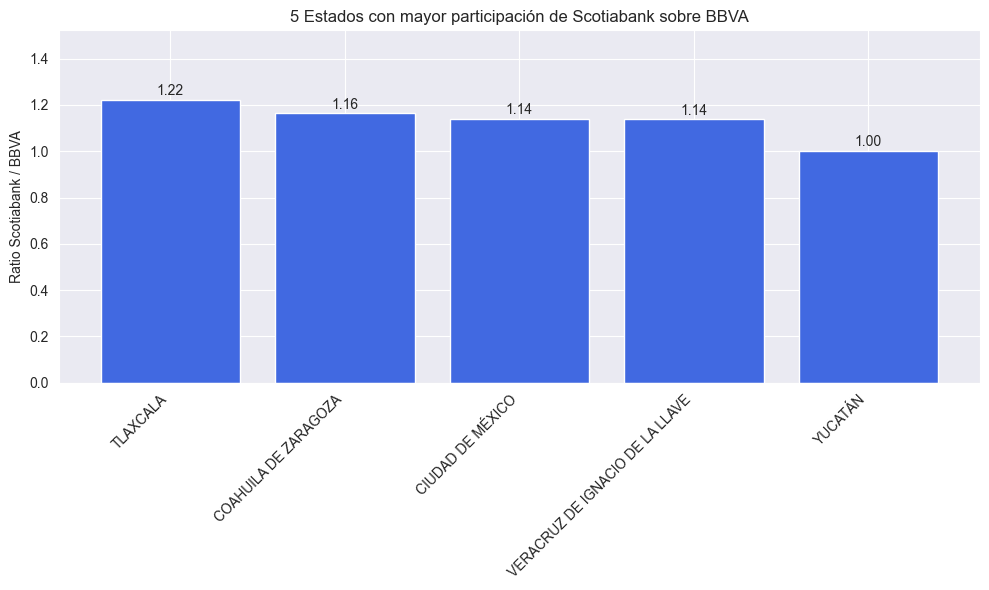

In [1487]:

states_BBVA_SCBNK["ratio_SCBNK_vs_BBVA"] = (
    states_BBVA_SCBNK["Scotiabank"] / states_BBVA_SCBNK["BBVA México"]
)

states_sorted = states_BBVA_SCBNK.sort_values("ratio_SCBNK_vs_BBVA", ascending=False)

# Top 5 y Bottom 5
top5_states = states_sorted.head(5)
bottom5_states = states_sorted.tail(5)

# Resetear el índice para que 'Estado' sea columna normal
top5_states = top5_states.reset_index().rename(columns={"index": "nombre_publicacion"})
bottom5_states = bottom5_states.reset_index().rename(columns={"index": "nombre_publicacion"})


# Función para graficar
def plot_ratio(df, title):
    plt.figure(figsize=(10,6))
    bars = plt.bar(df["dl_estado"], df["ratio_SCBNK_vs_BBVA"], color="royalblue")
    
    # Agregar valores sobre las barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center')
    
    plt.title(title)
    plt.ylabel("Ratio Scotiabank / BBVA")
    plt.ylim(0, df["ratio_SCBNK_vs_BBVA"].max() + 0.3)  # margen arriba
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Graficar top 5
plot_ratio(top5_states, "5 Estados con mayor participación de Scotiabank sobre BBVA")




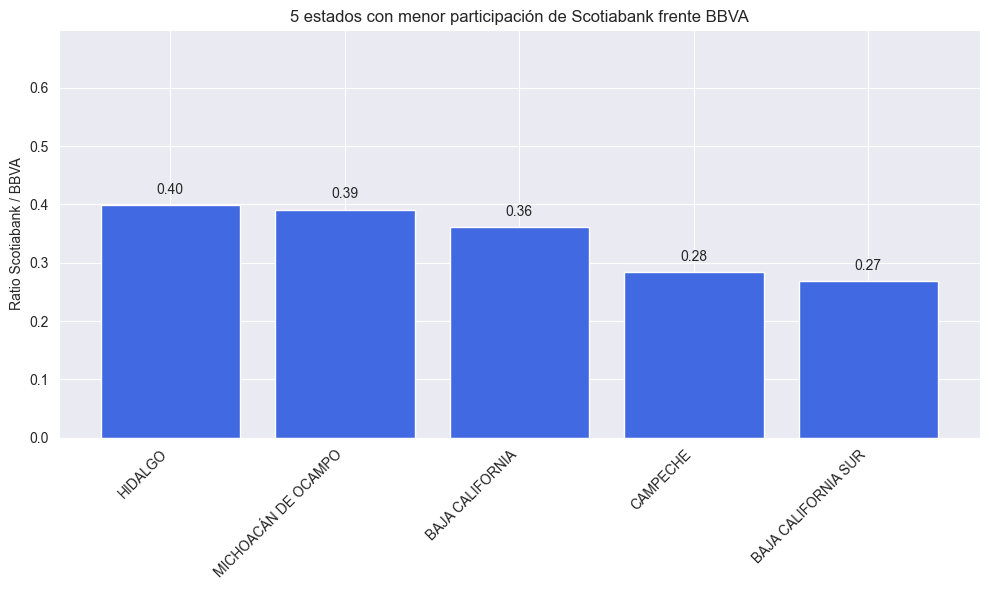

In [1488]:
# Graficar bottom 5
plot_ratio(bottom5_states, "5 estados con menor participación de Scotiabank frente BBVA")

In [1394]:
df_clean["dl_estado"].unique().tolist()

['SAN LUIS POTOSÍ',
 'VERACRUZ DE IGNACIO DE LA LLAVE',
 'YUCATÁN',
 'OAXACA',
 'CIUDAD DE MÉXICO',
 'PUEBLA',
 'COAHUILA DE ZARAGOZA',
 'TLAXCALA',
 'HIDALGO',
 'MICHOACÁN DE OCAMPO',
 'CHIAPAS',
 'MÉXICO',
 'BAJA CALIFORNIA SUR',
 'JALISCO',
 'TAMAULIPAS',
 'QUERÉTARO',
 'SINALOA',
 'NUEVO LEÓN',
 'QUINTANA ROO',
 'MORELOS',
 'SONORA',
 'COLIMA',
 'GUERRERO',
 'AGUASCALIENTES',
 'BAJA CALIFORNIA',
 'CHIHUAHUA',
 'CAMPECHE',
 'ZACATECAS',
 'GUANAJUATO',
 'NAYARIT',
 'TABASCO',
 'DURANGO']

In [1422]:
grouped = df_clean.groupby("nombre_publicacion").apply(
    lambda x: (x["tasa_ponderada"] * x["dat_monto_orig_cred"]).sum() / x["dat_monto_orig_cred"].sum()
)
grouped

C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\1674335730.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df_clean.groupby("nombre_publicacion").apply(


nombre_publicacion
Afirme                    9.894751
Autofin                  13.534793
BBVA México               9.469575
Banamex                   9.427449
Banca Mifel              12.367144
Banco Ahorro Famsa        6.500000
Banco Azteca              8.792157
Banco del Bajío          12.210102
Bancomext                 6.500000
Bancoppel                13.695477
Banjército                8.853053
Banobras                  6.944105
Banorte                   9.473860
Banregio                 10.442639
Bansí                    12.904068
CIBanco                  15.201347
HSBC                      9.650527
ION Financiera           16.781583
Inbursa                  10.392989
Inmobiliario Mexicano     8.472222
Invex                     9.002172
Metrofinanciera           8.000000
Monex                    16.329832
Multiva                  12.702436
Nafin                     6.801968
Sabadell                 12.000000
Santander                10.090353
Santander Vivienda        9.754885
S

In [1397]:
monto_banco_estado = df_clean.groupby(["dl_estado", "nombre_publicacion"])["dat_monto_orig_cred"].sum().reset_index()
monto_banco_estado

,dl_estado,nombre_publicacion,dat_monto_orig_cred
0,AGUASCALIENTES,Afirme,1.960335e+08
1,AGUASCALIENTES,BBVA México,4.205774e+09
2,AGUASCALIENTES,Banamex,2.996628e+09
3,AGUASCALIENTES,Banca Mifel,5.802469e+08
4,AGUASCALIENTES,Banco del Bajío,8.221457e+07
...,...,...,...
618,ZACATECAS,Monex,2.630217e+07
619,ZACATECAS,Santander,1.955197e+08
620,ZACATECAS,Santander Vivienda,3.084240e+07
621,ZACATECAS,Scotiabank,5.962786e+08


In [1398]:
total_estado = monto_banco_estado.groupby("dl_estado")["dat_monto_orig_cred"].sum().reset_index(name="total_estado")
total_estado

,dl_estado,total_estado
0,AGUASCALIENTES,2.239632e+10
1,BAJA CALIFORNIA,4.676075e+10
2,BAJA CALIFORNIA SUR,1.193573e+10
3,CAMPECHE,3.219756e+09
4,CHIAPAS,7.401837e+09
5,CHIHUAHUA,4.497917e+10
6,CIUDAD DE MÉXICO,2.036812e+11
7,COAHUILA DE ZARAGOZA,3.311320e+10
8,COLIMA,7.675089e+09
9,DURANGO,7.351760e+09


In [1399]:
# Merge
monto_banco_estado = monto_banco_estado.merge(total_estado, on="dl_estado")
monto_banco_estado["participacion"] = (monto_banco_estado["dat_monto_orig_cred"] / monto_banco_estado["total_estado"])*100

# Filtramos Scotiabank
scotia_part = monto_banco_estado[monto_banco_estado["nombre_publicacion"] == "Scotiabank"]



In [1400]:
# Segmentos donde su participación es más baja
scotia_low = scotia_part.sort_values("participacion")

In [1401]:
scotia_low

,dl_estado,nombre_publicacion,dat_monto_orig_cred,total_estado,participacion
35,BAJA CALIFORNIA,Scotiabank,3.778507e+09,4.676075e+10,8.080510
55,BAJA CALIFORNIA SUR,Scotiabank,1.025415e+09,1.193573e+10,8.591139
72,CAMPECHE,Scotiabank,3.085737e+08,3.219756e+09,9.583761
375,NUEVO LEÓN,Scotiabank,1.421206e+10,1.306034e+11,10.881842
290,MICHOACÁN DE OCAMPO,Scotiabank,2.080039e+09,1.821128e+10,11.421708
412,PUEBLA,Scotiabank,4.792625e+09,3.521349e+10,13.610197
231,GUERRERO,Scotiabank,1.457976e+09,1.047469e+10,13.919040
250,HIDALGO,Scotiabank,1.707949e+09,1.226310e+10,13.927550
16,AGUASCALIENTES,Scotiabank,3.154060e+09,2.239632e+10,14.082942
495,SINALOA,Scotiabank,6.128389e+09,4.286319e+10,14.297557


In [1402]:
# Monto total originado por banco y edad
monto_banco_edad = df_clean.groupby(["dat_ai_edad_acred", "nombre_publicacion"])["dat_monto_orig_cred"].sum().reset_index()

# Total por edad
total_edad = monto_banco_edad.groupby("dat_ai_edad_acred")["dat_monto_orig_cred"].sum().reset_index(name="total_edad")

# Merge
monto_banco_edad = monto_banco_edad.merge(total_edad, on="dat_ai_edad_acred")
monto_banco_edad["participacion"] = (monto_banco_edad["dat_monto_orig_cred"] / monto_banco_edad["total_edad"])*100

# Filtramos Scotiabank
scotia_part = monto_banco_edad[monto_banco_edad["nombre_publicacion"] == "Scotiabank"]

# Segmentos donde su participación es más baja
scotia_low = scotia_part.sort_values("participacion")


In [1403]:
scotia_low

,dat_ai_edad_acred,nombre_publicacion,dat_monto_orig_cred,total_edad,participacion
21,20,Scotiabank,1.175000e+06,4.285182e+09,0.027420
37,21,Scotiabank,4.606051e+06,5.481111e+08,0.840350
72,23,Scotiabank,8.829170e+07,2.044245e+09,4.319037
54,22,Scotiabank,7.205994e+07,1.149090e+09,6.271043
1004,66,Scotiabank,8.192936e+08,1.160049e+10,7.062581
90,24,Scotiabank,3.106003e+08,4.100275e+09,7.575109
1119,74,Scotiabank,3.635823e+07,3.379754e+08,10.757657
108,25,Scotiabank,1.045212e+09,8.194887e+09,12.754437
1039,68,Scotiabank,5.375126e+08,3.955381e+09,13.589399
126,26,Scotiabank,1.990641e+09,1.404753e+10,14.170754


In [1404]:
df_clean["dat_ai_edad_acred"].unique().tolist()


[54,
 47,
 40,
 44,
 26,
 49,
 53,
 35,
 69,
 31,
 45,
 55,
 36,
 37,
 56,
 46,
 39,
 34,
 33,
 58,
 67,
 32,
 38,
 43,
 61,
 50,
 59,
 29,
 74,
 60,
 41,
 48,
 51,
 25,
 42,
 27,
 73,
 28,
 68,
 71,
 24,
 57,
 62,
 30,
 52,
 64,
 72,
 76,
 22,
 21,
 23,
 66,
 63,
 65,
 20,
 70,
 19,
 77,
 18,
 79,
 78,
 75,
 80]

In [1489]:
# Definir rangos de edad
bins = [18, 34, 54, 74, 80]
labels = ['18-34', '35-54', '55-74', '75+']
df_clean['rango_edad'] = pd.cut(df_clean['dat_ai_edad_acred'], bins=bins, labels=labels, right=True)

# Recalcular agregaciones por rango
monto_banco_edad = df_clean.groupby(['rango_edad', 'nombre_publicacion'])['dat_monto_orig_cred'].sum().reset_index()

# Total por rango
total_edad = monto_banco_edad.groupby('rango_edad')['dat_monto_orig_cred'].sum().reset_index(name='total_edad')

# Merge y participación
monto_banco_edad = monto_banco_edad.merge(total_edad, on='rango_edad')
monto_banco_edad['participacion'] = (monto_banco_edad['dat_monto_orig_cred'] / monto_banco_edad['total_edad']) * 100

# Filtrar Scotiabank
scotia_part = monto_banco_edad[
    (monto_banco_edad['nombre_publicacion'] == 'Scotiabank') |
    (monto_banco_edad['nombre_publicacion'] == 'BBVA México')|
    (monto_banco_edad['nombre_publicacion'] == 'Banorte')|
    (monto_banco_edad['nombre_publicacion'] == 'Santander')
]
scotia_low = scotia_part.sort_values('participacion')


C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\1741166242.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monto_banco_edad = df_clean.groupby(['rango_edad', 'nombre_publicacion'])['dat_monto_orig_cred'].sum().reset_index()
C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\1741166242.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_edad = monto_banco_edad.groupby('rango_edad')['dat_monto_orig_cred'].sum().reset_index(name='total_edad')


In [1490]:
# Pivotear para tener columnas por banco
comparativa = scotia_part.pivot(
    index='rango_edad',
    columns='nombre_publicacion',
    values='participacion'
).reset_index()

# Calcular diferencia si quieres ver en qué rango Scotiabank tiene menor/ mayor participación
comparativa['Diferencia (SCBNK - BBVA)'] = comparativa['Scotiabank'] - comparativa['BBVA México']

# Mostrar
comparativa.sort_values('rango_edad')


nombre_publicacion,rango_edad,BBVA México,Banorte,Santander,Scotiabank,Diferencia (SCBNK - BBVA)
0,18-34,28.967227,16.344335,13.342064,16.340201,-12.627026
1,35-54,20.270366,18.899040,14.197246,18.388011,-1.882355
2,55-74,24.449613,22.262980,12.683715,16.768180,-7.681432
3,75+,77.455414,1.563916,0.188527,6.784673,-70.670742


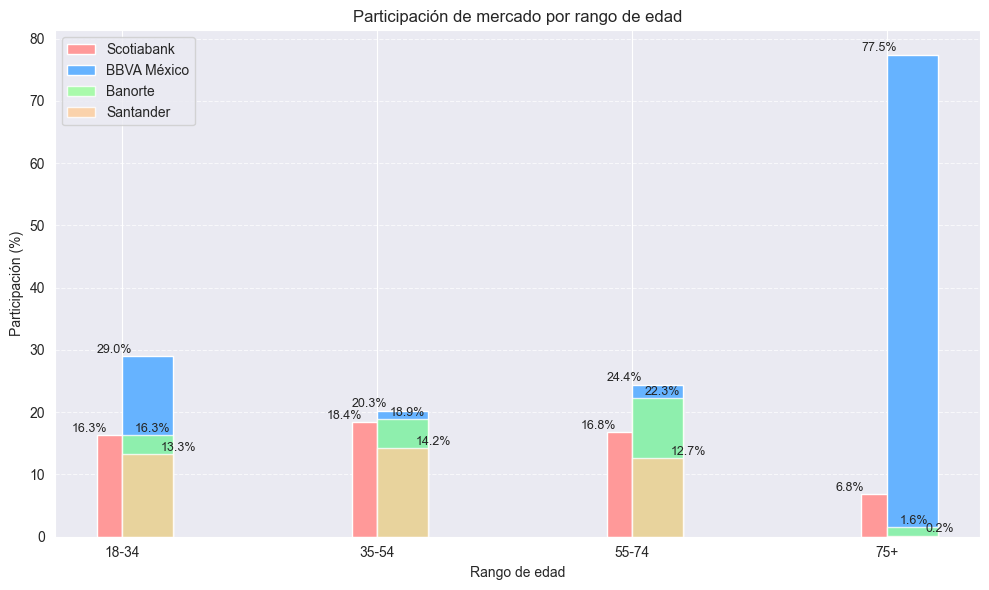

In [1492]:

plt.figure(figsize=(10,6))

# Definir posiciones en X
x = comparativa['rango_edad']
ancho = 0.2  # ancho de las barras

colors = {
    'Scotiabank': '#FF9999',   # rosa suave
    'BBVA México': '#66B3FF',  # azul suave
    'Banorte': '#99FF99',      # verde suave
    'Santander': '#FFCC99'     # naranja suave
}

plt.bar(x, comparativa['Scotiabank'], width=ancho, label='Scotiabank', color=colors['Scotiabank'], align='center')
plt.bar(x, comparativa['BBVA México'], width=ancho, label='BBVA México', color=colors['BBVA México'], align='edge')
plt.bar(x, comparativa['Banorte'], width=ancho, label='Banorte', color=colors['Banorte'], align='edge', alpha=0.8)
plt.bar(x, comparativa['Santander'], width=ancho, label='Santander', color=colors['Santander'], align='edge', alpha=0.8)
plt.title('Participación de mercado por rango de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Participación (%)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar valores sobre las barras
for i, row in comparativa.iterrows():
    plt.text(i-0.2, row['Scotiabank']+0.5, f"{row['Scotiabank']:.1f}%", fontsize=9)
    plt.text(i-0.1, row['BBVA México']+0.5, f"{row['BBVA México']:.1f}%", fontsize=9)
    plt.text(i+0.05, row['Banorte']+0.5, f"{row['Banorte']:.1f}%", fontsize=9)
    plt.text(i+0.15, row['Santander']+0.5, f"{row['Santander']:.1f}%", fontsize=9)

plt.tight_layout()
plt.show()


In [1407]:
df_clean["dat_ingreso_mensual_bruto"].unique().tolist()


[55737.68,
 23065.59,
 17034.54,
 53762.0,
 30589.15,
 99374.8,
 11574.68,
 36059.41,
 18960.38,
 91884.0,
 91896.0,
 91970.0,
 67832.0,
 67000.0,
 115782.96,
 16969.79,
 70507.0,
 33869.73,
 51315.6,
 69375.24,
 33229.52,
 26353.1,
 56189.1,
 14841.02,
 23728.05,
 34243.15,
 57554.49,
 117918.46,
 18493.64,
 23132.28,
 40709.28,
 56640.5,
 39754.17,
 140501.0,
 41843.58,
 28516.18,
 121953.06,
 143120.32,
 32306.69,
 176188.98,
 34601.07,
 18359.7,
 110462.7,
 36335.2,
 177738.98,
 40001.76,
 20969.19,
 10515.41,
 22275.46,
 23388.44,
 109378.06,
 115240.44,
 73348.26,
 52303.0,
 17473.45,
 49209.62,
 110852.91,
 23062.65,
 30095.5,
 49763.86,
 19333.5,
 113193.96,
 131195.76,
 48364.58,
 59595.14,
 54687.67,
 17792.71,
 28005.62,
 56279.03,
 74672.91,
 78830.3,
 61410.84,
 134248.12,
 135880.86,
 111133.26,
 31446.2,
 26846.22,
 60628.2,
 23834.98,
 43146.32,
 123975.92,
 81221.7,
 135574.82,
 73772.24,
 65591.96,
 160788.12,
 22167.48,
 78625.82,
 41415.49,
 34113.68,
 138253.38,
 1

In [1408]:
Q1 = df_clean["dat_ingreso_mensual_bruto"].quantile(0.25)
Q2 = df_clean["dat_ingreso_mensual_bruto"].quantile(0.50)
Q3 = df_clean["dat_ingreso_mensual_bruto"].quantile(0.75)
print(f"Q1: {Q1} , Q2: {Q2}, Q3: {Q3}")

Q1: 9049.78 , Q2: 21562.11, Q3: 58741.0


In [1409]:
df_clean["dat_ingreso_mensual_bruto"].max()

1156820.879999997

In [1495]:
# Paso 1: Definimos los intervalos o segmentos de monto
bins = [0, 22000, 60000, df_clean["dat_ingreso_mensual_bruto"].max()]
labels = [
    '≤22 mil',
    '22-60 mil',
    '>60 mil'
]

df_clean['segmento_monto'] = pd.cut(df_clean["dat_ingreso_mensual_bruto"], bins=bins, labels=labels, include_lowest=True)

# Paso 2: Agrupar por segmento y banco
monto_banco = df_clean.groupby(['segmento_monto', 'nombre_publicacion'])['dat_monto_orig_cred'].sum().reset_index()

# Paso 3: Total por segmento
total_monto = monto_banco.groupby('segmento_monto')['dat_monto_orig_cred'].sum().reset_index(name='total_segmento')

# Paso 4: Calcular participación por banco dentro de cada segmento
monto_banco = monto_banco.merge(total_monto, on='segmento_monto')
monto_banco['participacion'] = (monto_banco['dat_monto_orig_cred'] / monto_banco['total_segmento']) * 100

# Paso 5: Extraer participación de Scotiabank
scotia_part = monto_banco[
    (monto_banco['nombre_publicacion'] == 'Scotiabank') |
    (monto_banco['nombre_publicacion'] == 'BBVA México')|
    (monto_banco['nombre_publicacion'] == 'Banorte')|
    (monto_banco['nombre_publicacion'] == 'Santander')
]

# Paso 6: Ver segmentos donde su participación es menor
scotia_low = scotia_part.sort_values('participacion')


C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\3638159331.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monto_banco = df_clean.groupby(['segmento_monto', 'nombre_publicacion'])['dat_monto_orig_cred'].sum().reset_index()
C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\3638159331.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_monto = monto_banco.groupby('segmento_monto')['dat_monto_orig_cred'].sum().reset_index(name='total_segmento')


In [1496]:
scotia_low

,segmento_monto,nombre_publicacion,dat_monto_orig_cred,total_segmento,participacion
26,≤22 mil,Santander,4.078777e+09,1.349183e+11,3.023146
28,≤22 mil,Scotiabank,9.352532e+09,1.349183e+11,6.931998
56,22-60 mil,Santander,3.509724e+10,3.448033e+11,10.178917
86,>60 mil,Santander,1.303763e+11,7.541098e+11,17.288773
42,22-60 mil,Banorte,6.151505e+10,3.448033e+11,17.840622
58,22-60 mil,Scotiabank,6.355482e+10,3.448033e+11,18.432196
72,>60 mil,Banorte,1.442521e+11,7.541098e+11,19.128787
88,>60 mil,Scotiabank,1.444410e+11,7.541098e+11,19.153846
12,≤22 mil,Banorte,2.586929e+10,1.349183e+11,19.174042
62,>60 mil,BBVA México,1.564666e+11,7.541098e+11,20.748518


In [1497]:
# Pivotear para tener columnas por banco
comparativa = scotia_part.pivot(
    index='segmento_monto',
    columns='nombre_publicacion',
    values='participacion'
).reset_index()
comparativa.sort_values('segmento_monto')


nombre_publicacion,segmento_monto,BBVA México,Banorte,Santander,Scotiabank
0,≤22 mil,39.593893,19.174042,3.023146,6.931998
1,22-60 mil,21.901779,17.840622,10.178917,18.432196
2,>60 mil,20.748518,19.128787,17.288773,19.153846


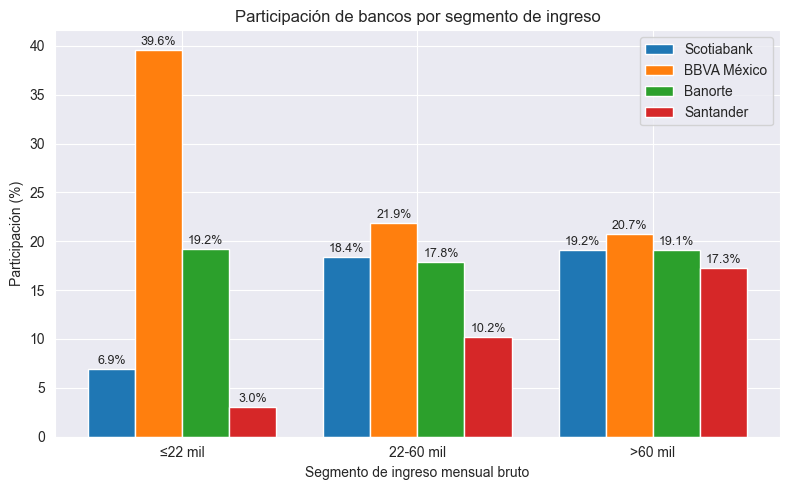

In [1500]:

# Configuración básica
fig, ax = plt.subplots(figsize=(8,5))

# Definir los bancos
bancos = ['Scotiabank', 'BBVA México', 'Banorte', 'Santander']

# Posición de las barras
x = range(len(comparativa['segmento_monto']))

# Ancho de cada barra
width = 0.2

# Graficar cada banco
for i, banco in enumerate(bancos):
    ax.bar([p + i*width for p in x], comparativa[banco], width=width, label=banco)

# Labels y título
ax.set_xticks([p + 1.5*width for p in x])
ax.set_xticklabels(comparativa['segmento_monto'])
ax.set_ylabel('Participación (%)')
ax.set_xlabel('Segmento de ingreso mensual bruto')
ax.set_title('Participación de bancos por segmento de ingreso')
ax.legend()

# Mostrar valores encima de cada barra
for i, banco in enumerate(bancos):
    for j, val in enumerate(comparativa[banco]):
        ax.text(j + i*width, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


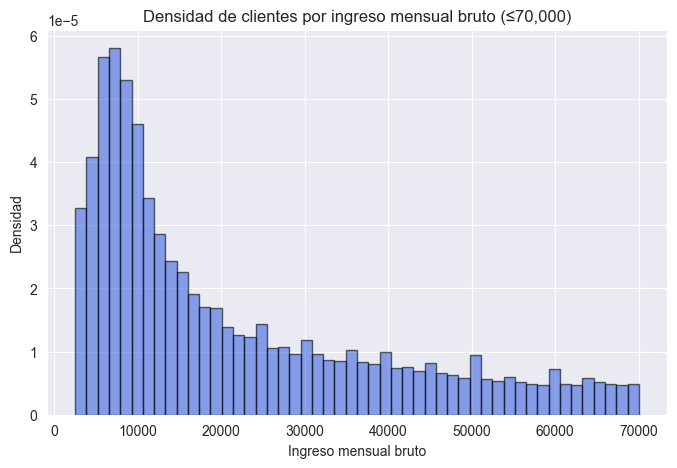

In [1510]:
# Filtrar ingresos ≤ 500,000
df_filtered = df_clean[df_clean["dat_ingreso_mensual_bruto"] <= 70000]

plt.figure(figsize=(8,5))
plt.hist(
    df_filtered["dat_ingreso_mensual_bruto"], 
    bins=50,                 # número de barras
    density=True,            # normaliza para que sea densidad
    color='royalblue', 
    alpha=0.6, 
    edgecolor='black'
)

plt.title("Densidad de clientes por ingreso mensual bruto (≤70,000)")
plt.xlabel("Ingreso mensual bruto")
plt.ylabel("Densidad")
plt.show()

In [1456]:
months = df_clean[df_clean['cve_periodo'].isin([202311,202312,202401,202402])]
months

,cve_periodo,nombre_publicacion,dl_estado,tipo_acreditado,dl_tipo_comprobacion,dl_genero,dl_destino_credito,dat_ingreso_mensual_bruto,dat_valor_vivienda_originacion,dat_ai_edad_acred,dat_monto_orig_cred,tasa_ponderada,rango_edad,segmento_monto
198,202311,Banjército,CHIAPAS,Asalariado Público,Asalariado,Masculino,Adquisición de Terreno para Vivienda,12544.50,568000.0,41,511200.00,10.0,35-44,≤22 mil
199,202311,Banjército,CIUDAD DE MÉXICO,Asalariado Público,Asalariado,Masculino,Crédito Para Liquidez,73580.81,6981000.0,42,2000000.00,13.0,35-44,>60 mil
200,202311,Banjército,CIUDAD DE MÉXICO,Asalariado Público,Asalariado,Femenino,Adquisición de Vivienda Usada,19813.76,3035000.0,49,935000.00,9.0,45-54,≤22 mil
201,202311,Banjército,PUEBLA,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Nueva,47490.93,2405000.0,42,520000.00,9.0,35-44,22-60 mil
202,202311,Banjército,YUCATÁN,Asalariado Público,Asalariado,Masculino,Adquisición de Vivienda Nueva,66805.12,3638000.0,33,2658000.00,9.0,25-34,>60 mil
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292749,202402,Scotiabank,YUCATÁN,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Nueva,74731.62,1547000.0,47,1408419.00,10.5,45-54,>60 mil
1292750,202402,Scotiabank,YUCATÁN,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Nueva,210000.00,1850000.0,28,1448366.44,10.5,25-34,>60 mil
1292751,202402,Scotiabank,ZACATECAS,Asalariado Privado,Asalariado,Femenino,Adquisición de Vivienda Nueva,11611.25,1468000.0,41,1243935.81,10.5,35-44,≤22 mil
1292752,202402,Scotiabank,ZACATECAS,Asalariado Privado,Asalariado,Masculino,Adquisición de Vivienda Nueva,37228.44,660000.0,34,594000.00,10.5,25-34,22-60 mil


In [1457]:
state_rate = months.groupby("dl_estado").apply(
    lambda x: (x["tasa_ponderada"] * x["dat_monto_orig_cred"]).sum() / x["dat_monto_orig_cred"].sum()
)
state_rate=pd.DataFrame(state_rate).reset_index()

C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\2095003861.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_rate = months.groupby("dl_estado").apply(


In [1458]:
scotiabank_months = months[months["nombre_publicacion"] == 'Scotiabank']

In [1459]:
scotiabank_months_rate = scotiabank_months.groupby("dl_estado").apply(
    lambda x: (x["tasa_ponderada"] * x["dat_monto_orig_cred"]).sum() / x["dat_monto_orig_cred"].sum()
)
scotiabank_months_rate = pd.DataFrame(scotiabank_months_rate).reset_index()


C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\4173800840.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scotiabank_months_rate = scotiabank_months.groupby("dl_estado").apply(


In [1460]:
# Crear DataFrames con nombre de columna
state_rate.columns = ['dl_estado', 'tasa_promedio_general']


scotiabank_months_rate.columns = ['dl_estado', 'tasa_promedio_scotiabank']

# Unir ambos DataFrames por estado
comparativa_tasas = state_rate.merge(scotiabank_months_rate, on='dl_estado', how='inner')

# Calcular la diferencia entre Scotiabank y el promedio
comparativa_tasas['diferencia'] = comparativa_tasas['tasa_promedio_scotiabank'] - comparativa_tasas['tasa_promedio_general']

# Ordenar para ver más fácil dónde Scotiabank cobra más o menos
comparativa_tasas = comparativa_tasas.sort_values('diferencia', ascending=False)

comparativa_tasas


,dl_estado,tasa_promedio_general,tasa_promedio_scotiabank,diferencia
1,BAJA CALIFORNIA,10.481079,10.890987,0.409908
2,BAJA CALIFORNIA SUR,10.495517,10.905304,0.409787
18,NUEVO LEÓN,10.235850,10.614852,0.379001
24,SINALOA,10.566097,10.924527,0.358431
22,QUINTANA ROO,10.331878,10.654973,0.323095
11,GUERRERO,10.663951,10.947297,0.283345
16,MÉXICO,10.414190,10.683586,0.269396
25,SONORA,10.298910,10.546330,0.247420
9,DURANGO,10.658092,10.895433,0.237341
6,CIUDAD DE MÉXICO,10.436032,10.657016,0.220983


In [1454]:
comparativa_tasas["diferencia"].max()

0.39043754501026307

In [1512]:
months = df_clean[df_clean['cve_periodo'].isin([202311, 202312, 202401, 202402])]
months = months[(months['nombre_publicacion'] == 'Scotiabank') |
    (months['nombre_publicacion'] == 'BBVA México')|
    (months['nombre_publicacion'] == 'Banorte')|
    (months['nombre_publicacion'] == 'Santander')| 
    (months['nombre_publicacion'] == 'HSBC')
    ]

state_rate = months.groupby("dl_estado").apply(
    lambda x: (x["tasa_ponderada"] * x["dat_monto_orig_cred"]).sum() / x["dat_monto_orig_cred"].sum()
)
state_rate = pd.DataFrame(state_rate).reset_index()
scotiabank_months = months[months["nombre_publicacion"] == 'Scotiabank']
scotiabank_months_rate = scotiabank_months.groupby("dl_estado").apply(
    lambda x: (x["tasa_ponderada"] * x["dat_monto_orig_cred"]).sum() / x["dat_monto_orig_cred"].sum()
)
scotiabank_months_rate = pd.DataFrame(scotiabank_months_rate).reset_index()

# Crear DataFrames con nombre de columna
state_rate.columns = ['dl_estado', 'tasa_promedio_general']

scotiabank_months_rate.columns = ['dl_estado', 'tasa_promedio_scotiabank']

# Unir ambos DataFrames por estado
comparativa_tasas = state_rate.merge(scotiabank_months_rate, on='dl_estado', how='inner')

# Calcular la diferencia entre Scotiabank y el promedio
comparativa_tasas['diferencia'] = comparativa_tasas['tasa_promedio_scotiabank'] - comparativa_tasas[
    'tasa_promedio_general']

# Ordenar para ver más fácil dónde Scotiabank cobra más o menos
comparativa_tasas = comparativa_tasas.sort_values('diferencia', ascending=False)

comparativa_tasas

C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\4276425434.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_rate = months.groupby("dl_estado").apply(
C:\Users\JPabl\AppData\Local\Temp\ipykernel_22656\4276425434.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scotiabank_months_rate = scotiabank_months.groupby("dl_estado").apply(


,dl_estado,tasa_promedio_general,tasa_promedio_scotiabank,diferencia
2,BAJA CALIFORNIA SUR,10.494629,10.905304,0.410674
1,BAJA CALIFORNIA,10.494399,10.890987,0.396588
18,NUEVO LEÓN,10.237690,10.614852,0.377162
24,SINALOA,10.567566,10.924527,0.356961
22,QUINTANA ROO,10.324209,10.654973,0.330764
25,SONORA,10.297135,10.546330,0.249195
16,MÉXICO,10.453984,10.683586,0.229602
6,CIUDAD DE MÉXICO,10.451773,10.657016,0.205243
11,GUERRERO,10.748073,10.947297,0.199224
9,DURANGO,10.719655,10.895433,0.175779


In [1527]:
# Ordenar por diferencia
comparativa_tasas_sorted = comparativa_tasas.sort_values('diferencia', ascending=False)

# Top 5 y bottom 5
top5 = comparativa_tasas_sorted.head(5)
bottom5 = comparativa_tasas_sorted.tail(5)


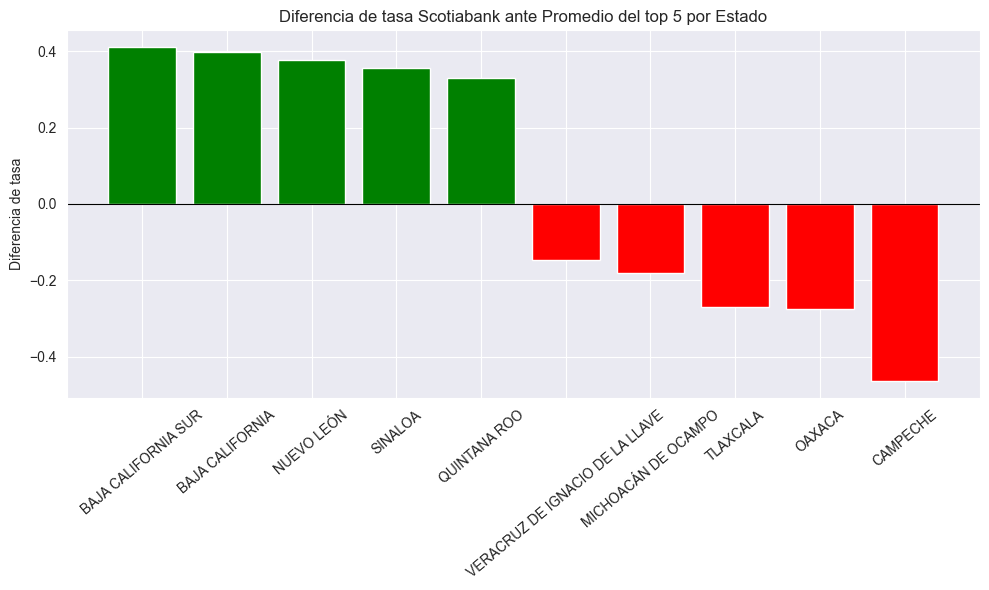

In [1530]:
# Unir top y bottom para comparar
combined = pd.concat([top5, bottom5])

plt.figure(figsize=(10,6))
bars = plt.bar(combined['dl_estado'], combined['diferencia'], color=['green']*5 + ['red']*5)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Diferencia de tasa Scotiabank ante Promedio del top 5 por Estado')
plt.ylabel('Diferencia de tasa')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

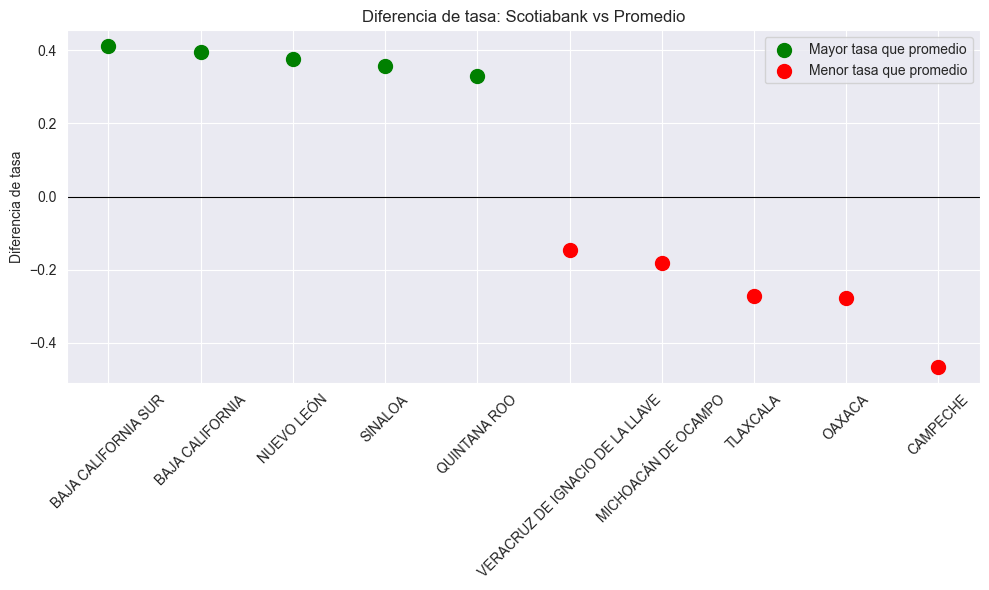

In [1529]:
plt.figure(figsize=(10,6))
plt.scatter(top5['dl_estado'], top5['diferencia'], color='green', s=100, label='Mayor tasa que promedio')
plt.scatter(bottom5['dl_estado'], bottom5['diferencia'], color='red', s=100, label='Menor tasa que promedio')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Diferencia de tasa: Scotiabank vs Promedio')
plt.ylabel('Diferencia de tasa')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
